Student Performance Table


,Student,Mathematics,Science,English,Total,Average
0,Alice,85,82,88,255,85.000000
1,Bob,72,75,79,226,75.333333
2,Charlie,90,94,89,273,91.000000
3,Diana,68,70,74,212,70.666667
4,Ethan,78,80,76,234,78.000000
5,Fatima,88,91,86,265,88.333333


Class Statistics
Class average mark: 81.39
Highest individual mark: 94
Highest student average: 91.00
Top-performing student: Charlie

Performance Comparison: Alice
Mathematics: 85 (class average: 80.17, difference: +4.83)
Science: 82 (class average: 82.00, difference: +0.00)
English: 88 (class average: 82.00, difference: +6.00)


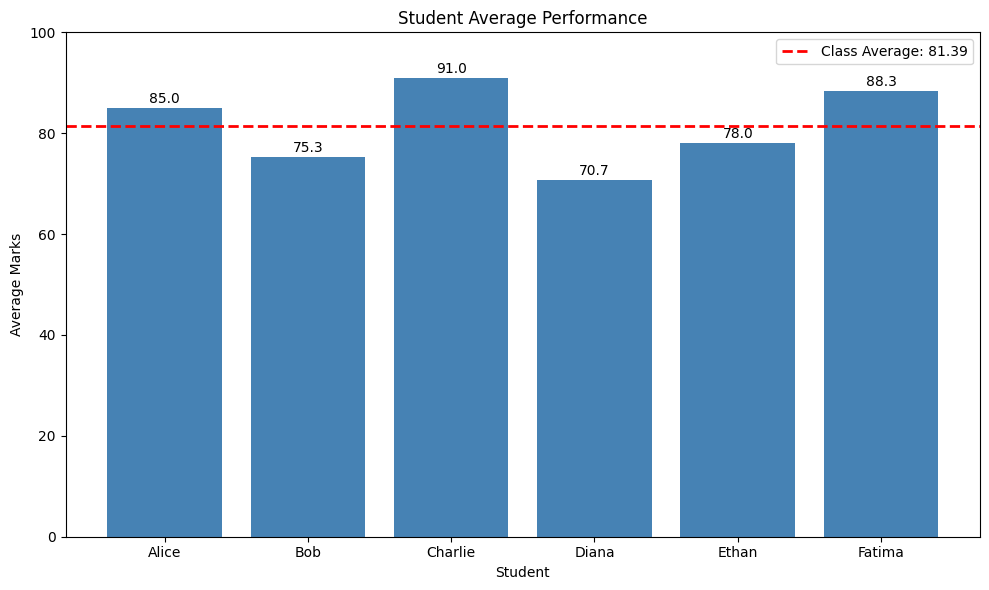

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Student marks data
students = pd.DataFrame({
    "Student": ["Alice", "Bob", "Charlie", "Diana", "Ethan", "Fatima"],
    "Mathematics": [85, 72, 90, 68, 78, 88],
    "Science": [82, 75, 94, 70, 80, 91],
    "English": [88, 79, 89, 74, 76, 86]
})

subjects = ["Mathematics", "Science", "English"]

# Calculate individual total and average marks
students["Total"] = students[subjects].sum(axis=1)
students["Average"] = students[subjects].mean(axis=1)

# Class statistics using NumPy
class_average = np.mean(students[subjects].values)
highest_mark = np.max(students[subjects].values)
highest_average = students["Average"].max()
top_student = students.loc[students["Average"].idxmax(), "Student"]

# Display student table
print("Student Performance Table")
display(students)

# Display class statistics
print("Class Statistics")
print(f"Class average mark: {class_average:.2f}")
print(f"Highest individual mark: {highest_mark}")
print(f"Highest student average: {highest_average:.2f}")
print(f"Top-performing student: {top_student}")

# Compare an individual student with the class
selected_student = "Alice"
student_record = students[students["Student"] == selected_student].iloc[0]

print(f"\nPerformance Comparison: {selected_student}")
for subject in subjects:
    subject_class_average = np.mean(students[subject])
    difference = student_record[subject] - subject_class_average
    print(
        f"{subject}: {student_record[subject]} "
        f"(class average: {subject_class_average:.2f}, "
        f"difference: {difference:+.2f})"
    )

# Bar chart of student averages with class average reference line
plt.figure(figsize=(10, 6))
bars = plt.bar(students["Student"], students["Average"], color="steelblue")

plt.axhline(
    y=students["Average"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Class Average: {students['Average'].mean():.2f}"
)

plt.title("Student Average Performance")
plt.xlabel("Student")
plt.ylabel("Average Marks")
plt.ylim(0, 100)
plt.legend()

for bar, average in zip(bars, students["Average"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{average:.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()